# Análisis de Vulnerabilidad Social — Departamento de Cortés

Este notebook cruza dos fuentes de datos para construir un índice de vulnerabilidad compuesto por municipio en Cortés, Honduras:

| Dataset | Descripción |
|---------|-------------|
| `preseleccion_solar_cortes.csv` | Índice de Potencial Solar (IPS), seguridad climática, infraestructura y capacidad adaptativa por municipio |
| `perfiles_municipales_cortes.csv` | IDH, IDS, ingreso per cápita, densidad y viviendas por municipio |

**Objetivo:** identificar qué municipios combinan alta vulnerabilidad socioeconómica con alto potencial solar, priorizando aquellos donde un proyecto de energía solar tendría mayor impacto social.

## 1. Configuración e importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

# Estilo global
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = {
    'alta': '#d62728',
    'media': '#ff7f0e',
    'baja': '#2ca02c',
}
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga y exploración de los datos

In [2]:
# ── Rutas relativas desde notebooks/ ─────────────────────────────────────────
PATH_SOLAR  = '../data/index/processed/preseleccion_solar_cortes.csv'
PATH_PERFIL = '../data/perfil_municipal_cortes/perfiles_municipales_cortes.csv'

df_solar  = pd.read_csv(PATH_SOLAR)
df_perfil = pd.read_csv(PATH_PERFIL)

print(f'preseleccion_solar_cortes  : {df_solar.shape[0]} filas × {df_solar.shape[1]} columnas')
print(f'perfiles_municipales_cortes: {df_perfil.shape[0]} filas × {df_perfil.shape[1]} columnas')
print()
print('--- preseleccion_solar_cortes (primeras 5 filas) ---')
display(df_solar.head())
print()
print('--- perfiles_municipales_cortes ---')
display(df_perfil)

preseleccion_solar_cortes  : 12 filas × 13 columnas
perfiles_municipales_cortes: 12 filas × 7 columnas

--- preseleccion_solar_cortes (primeras 5 filas) ---


,departamento,municipio,codigo_departamental,codigo_municipal,potencial_solar,seguridad_climatica,infraestructura,capacidad_adaptativa,IPS,tercil_potencial_solar,tercil_seguridad_climatica,tercil_infraestructura,preseleccionado
0,Cortes,Potrerillos,HN05,HN0505,1.000000,0.578352,0.700,0.812128,0.806407,Alto,Alto,Alto,True
1,Cortes,San Antonio De Cortes,HN05,HN0507,0.863164,0.623859,1.000,0.495461,0.775550,Medio,Alto,Alto,False
2,Cortes,Pimienta,HN05,HN0504,0.944454,0.630979,0.575,0.605848,0.741404,Alto,Alto,Alto,True
3,Cortes,San Francisco De Yojoa,HN05,HN0508,0.955035,0.755433,0.375,0.497230,0.720457,Alto,Alto,Bajo,False
4,Cortes,La Lima,HN05,HN0512,0.950176,0.304798,0.400,0.549143,0.618641,Alto,Bajo,Medio,False



--- perfiles_municipales_cortes ---


,Código,Municipio,IDH,IDS,ingres_per_capita,viviendas,personas_por_km2
0,501,San Pedro Sula,0.708,0.86,9331,2672783,917
1,502,Choloma,0.668,0.85,8117,79985,2648
2,503,Omoa,0.604,0.84,4309,15112,148
3,504,Pimienta,0.650,0.85,6316,6583,382
4,505,Potrerillos,0.639,0.85,6442,7477,304
5,506,Puerto Cortés,0.672,0.85,6884,37063,359
6,507,San Antonio de Cortés,0.586,0.83,4154,6123,472
7,508,San Francisco de Yojoa,0.643,0.84,5823,5857,267
8,509,San Manuel,0.656,0.84,6189,19181,536
9,510,Santa Cruz de Yojoa,0.622,0.84,5014,26194,133


In [3]:
# Estadísticas descriptivas
print('=== Estadísticas: preseleccion_solar ===')
display(df_solar.describe().round(3))
print()
print('=== Estadísticas: perfiles_municipales ===')
display(df_perfil.describe().round(3))

=== Estadísticas: preseleccion_solar ===


,potencial_solar,seguridad_climatica,infraestructura,capacidad_adaptativa,IPS
count,12.000,12.000,12.000,12.000,12.000
mean,0.734,0.391,0.448,0.552,0.564
std,0.356,0.221,0.261,0.133,0.213
min,0.000,0.015,0.000,0.262,0.086
25%,0.745,0.307,0.337,0.499,0.514
50%,0.888,0.331,0.425,0.532,0.601
75%,0.946,0.590,0.587,0.607,0.726
max,1.000,0.755,1.000,0.812,0.806



=== Estadísticas: perfiles_municipales ===


,Código,IDH,IDS,ingres_per_capita,viviendas,personas_por_km2
count,12.000,12.000,12.000,12.000,12.000,12.000
mean,506.500,0.652,0.846,6502.000,245922.000,620.333
std,3.606,0.036,0.008,1567.309,764585.551,678.845
min,501.000,0.586,0.830,4154.000,5857.000,133.000
25%,503.750,0.635,0.840,5620.750,7253.500,294.750
50%,506.500,0.653,0.850,6379.000,20774.500,427.000
75%,509.250,0.669,0.850,7585.250,40881.750,592.000
max,512.000,0.708,0.860,9331.000,2672783.000,2648.000


In [4]:
# Valores faltantes
print('Valores faltantes — preseleccion_solar:')
print(df_solar.isnull().sum())
print()
print('Valores faltantes — perfiles_municipales:')
print(df_perfil.isnull().sum())

Valores faltantes — preseleccion_solar:
departamento                  0
municipio                     0
codigo_departamental          0
codigo_municipal              0
potencial_solar               0
seguridad_climatica           0
infraestructura               0
capacidad_adaptativa          0
IPS                           0
tercil_potencial_solar        0
tercil_seguridad_climatica    0
tercil_infraestructura        0
preseleccionado               0
dtype: int64

Valores faltantes — perfiles_municipales:
Código               0
Municipio            0
IDH                  0
IDS                  0
ingres_per_capita    0
viviendas            0
personas_por_km2     0
dtype: int64


## 3. Cruce (merge) de los datasets

La clave de unión es el nombre del municipio, normalizado para eliminar diferencias tipográficas (tildes, mayúsculas, espacios).

In [5]:
def normalizar(s: pd.Series) -> pd.Series:
    """Normaliza texto: minúsculas, sin tildes, sin espacios extra."""
    return (
        s.str.lower()
         .str.strip()
         .str.replace('á', 'a').str.replace('é', 'e')
         .str.replace('í', 'i').str.replace('ó', 'o')
         .str.replace('ú', 'u').str.replace('ü', 'u')
         .str.replace(r'\s+', ' ', regex=True)
    )

df_solar['_key']  = normalizar(df_solar['municipio'])
df_perfil['_key'] = normalizar(df_perfil['Municipio'])

print('Claves en solar :', sorted(df_solar['_key'].tolist()))
print('Claves en perfil:', sorted(df_perfil['_key'].tolist()))

Claves en solar : ['choloma', 'la lima', 'omoa', 'pimienta', 'potrerillos', 'puerto cortes', 'san antonio de cortes', 'san francisco de yojoa', 'san manuel', 'san pedro sula', 'santa cruz de yojoa', 'villanueva']
Claves en perfil: ['choloma', 'la lima', 'omoa', 'pimienta', 'potrerillos', 'puerto cortes', 'san antonio de cortes', 'san francisco de yojoa', 'san manuel', 'san pedro sula', 'santa cruz de yojoa', 'villanueva']


In [6]:
# Merge outer para detectar posibles discrepancias
df = df_solar.merge(df_perfil, on='_key', how='outer', indicator=True)

print('Resultado del merge:')
print(df['_merge'].value_counts())
print()

# Sólo municipios con datos en ambas fuentes
df = df[df['_merge'] == 'both'].copy().drop(columns=['_merge', '_key', 'Municipio'])
df.reset_index(drop=True, inplace=True)

print(f'Municipios con datos completos en ambas fuentes: {len(df)}')
display(df[['municipio', 'potencial_solar', 'IPS', 'IDH', 'IDS',
            'ingres_per_capita', 'preseleccionado']].round(3))

Resultado del merge:
_merge
both          12
left_only      0
right_only     0
Name: count, dtype: int64

Municipios con datos completos en ambas fuentes: 12


,municipio,potencial_solar,IPS,IDH,IDS,ingres_per_capita,preseleccionado
0,Choloma,0.576,0.404,0.668,0.85,8117,False
1,La Lima,0.950,0.619,0.703,0.85,7997,False
2,Omoa,0.000,0.282,0.604,0.84,4309,False
3,Pimienta,0.944,0.741,0.650,0.85,6316,True
4,Potrerillos,1.000,0.806,0.639,0.85,6442,True
5,Puerto Cortes,0.861,0.551,0.672,0.85,6884,False
6,San Antonio De Cortes,0.863,0.776,0.586,0.83,4154,False
7,San Francisco De Yojoa,0.955,0.720,0.643,0.84,5823,False
8,San Manuel,0.912,0.612,0.656,0.84,6189,False
9,San Pedro Sula,0.018,0.086,0.708,0.86,9331,False


## 4. Construcción del Índice de Vulnerabilidad Social (IVS)

El IVS se construye como promedio ponderado de tres sub-dimensiones normalizadas a [0, 1]. **A mayor IVS, mayor vulnerabilidad**.

| Componente | Variable fuente | Peso | Interpretación |
|---|---|---|---|
| Desarrollo humano invertido | `IDH` | 40 % | Bajo IDH → alta vulnerabilidad |
| Precariedad de ingresos | `ingres_per_capita` | 35 % | Bajo ingreso → alta vulnerabilidad |
| Baja capacidad adaptativa | `capacidad_adaptativa` | 25 % | Baja capacidad → alta vulnerabilidad |

In [7]:
scaler = MinMaxScaler()

cols_vul = ['IDH', 'ingres_per_capita', 'capacidad_adaptativa']
df_norm = pd.DataFrame(
    scaler.fit_transform(df[cols_vul]),
    columns=cols_vul
)
# Invertir: 1 = más vulnerable
for col in cols_vul:
    df[f'{col}_vul'] = 1 - df_norm[col]

# IVS ponderado
PESOS = {
    'IDH_vul':                  0.40,
    'ingres_per_capita_vul':    0.35,
    'capacidad_adaptativa_vul': 0.25,
}
df['IVS'] = sum(df[col] * peso for col, peso in PESOS.items())

# Clasificar en terciles
df['nivel_vulnerabilidad'] = pd.qcut(
    df['IVS'], q=3,
    labels=['Baja', 'Media', 'Alta'],
    duplicates='drop'
)

display(
    df[['municipio', 'IDH_vul', 'ingres_per_capita_vul',
        'capacidad_adaptativa_vul', 'IVS', 'nivel_vulnerabilidad']]
    .sort_values('IVS', ascending=False)
    .round(3)
    .reset_index(drop=True)
)

,municipio,IDH_vul,ingres_per_capita_vul,capacidad_adaptativa_vul,IVS,nivel_vulnerabilidad
0,San Antonio De Cortes,1.000,1.000,0.576,0.894,Alta
1,Santa Cruz De Yojoa,0.705,0.834,1.000,0.824,Alta
2,Omoa,0.852,0.970,0.544,0.817,Alta
3,San Francisco De Yojoa,0.533,0.678,0.573,0.593,Alta
4,San Manuel,0.426,0.607,0.499,0.508,Media
5,Pimienta,0.475,0.582,0.375,0.488,Media
6,Potrerillos,0.566,0.558,0.000,0.422,Media
7,Villanueva,0.336,0.364,0.519,0.392,Media
8,Puerto Cortes,0.295,0.473,0.365,0.375,Baja
9,Choloma,0.328,0.234,0.188,0.260,Baja


## 5. Análisis exploratorio visual

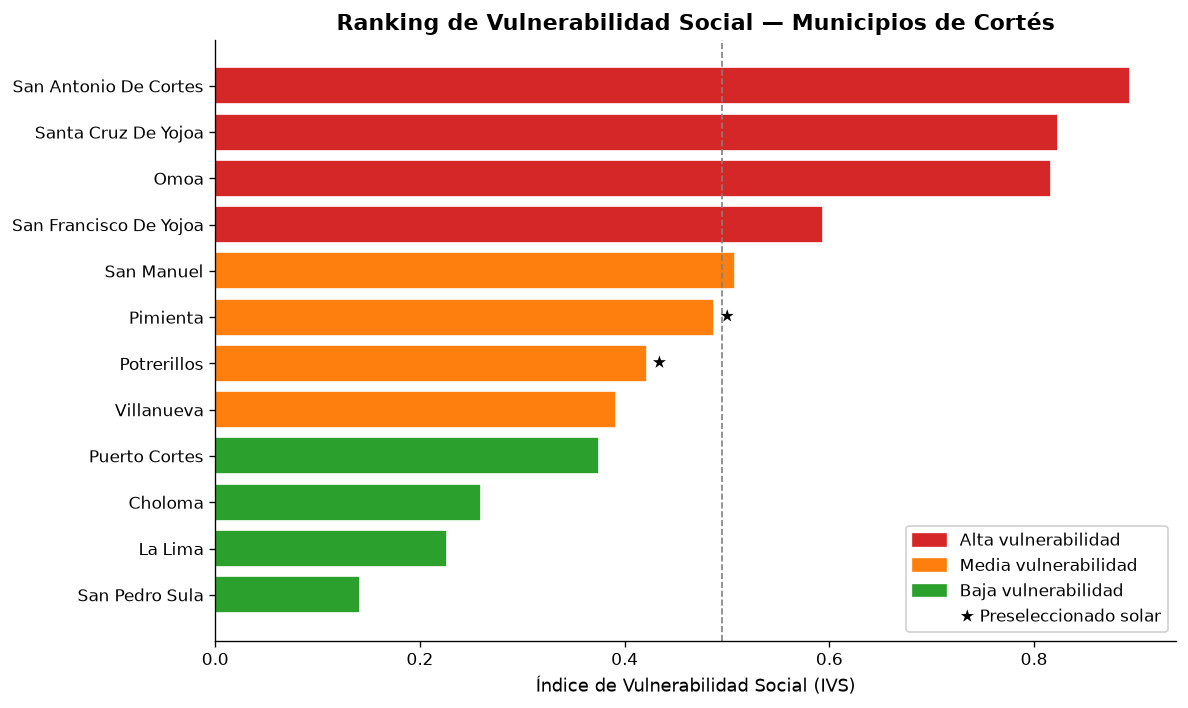

✓ Figura guardada: outputs/ivs_ranking_cortes.png


In [8]:
os.makedirs('../outputs', exist_ok=True)

# ── 5.1 Ranking de IVS por municipio ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
df_sorted = df.sort_values('IVS', ascending=True)
colores = df_sorted['nivel_vulnerabilidad'].map(
    {'Alta': PALETTE['alta'], 'Media': PALETTE['media'], 'Baja': PALETTE['baja']}
)

ax.barh(df_sorted['municipio'], df_sorted['IVS'], color=colores, edgecolor='white')

for i, (_, row) in enumerate(df_sorted.iterrows()):
    if row['preseleccionado']:
        ax.text(row['IVS'] + 0.005, i, '★', va='center', fontsize=10, fontweight='bold')

patches = [
    mpatches.Patch(color=PALETTE['alta'],  label='Alta vulnerabilidad'),
    mpatches.Patch(color=PALETTE['media'], label='Media vulnerabilidad'),
    mpatches.Patch(color=PALETTE['baja'],  label='Baja vulnerabilidad'),
    mpatches.Patch(color='white', label='★ Preseleccionado solar'),
]
ax.legend(handles=patches, loc='lower right', framealpha=0.9)
ax.axvline(df['IVS'].mean(), color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('Índice de Vulnerabilidad Social (IVS)', fontsize=11)
ax.set_title('Ranking de Vulnerabilidad Social — Municipios de Cortés',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/ivs_ranking_cortes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: outputs/ivs_ranking_cortes.png')

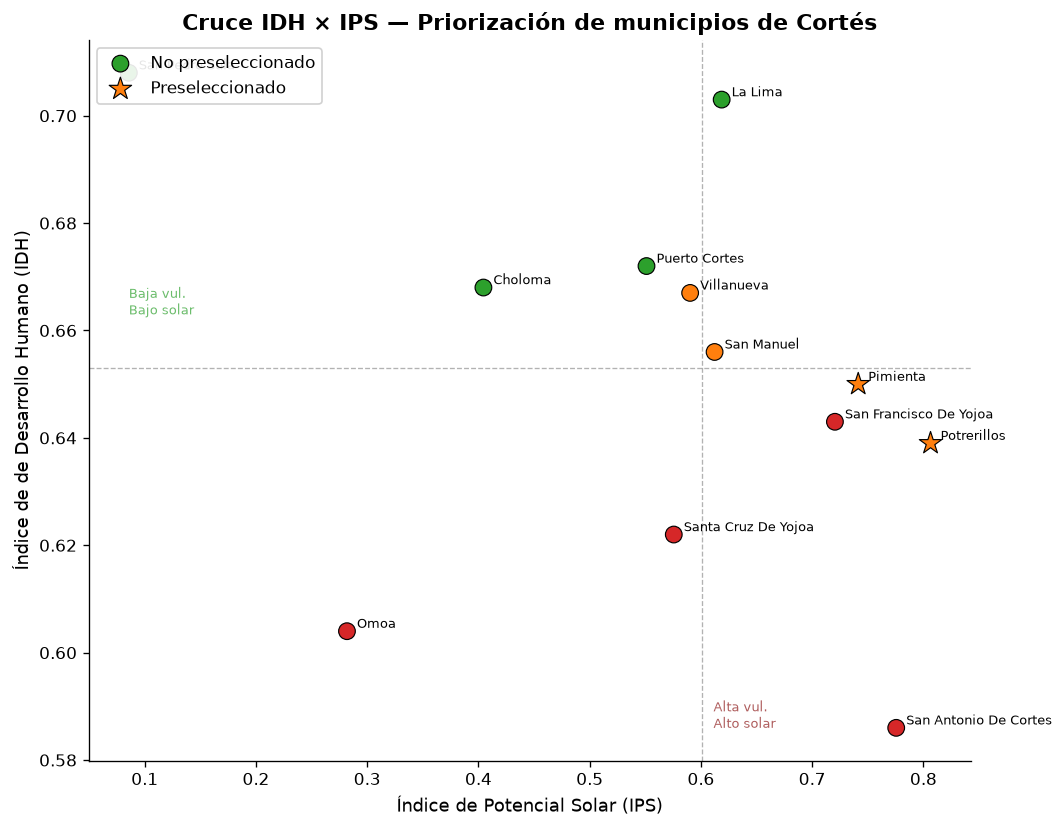

✓ Figura guardada: outputs/idh_vs_ips_scatter_cortes.png


In [25]:
# ── 5.2 Scatter: IVS vs IPS — cuadrantes estratégicos ────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for presel, grp in df.groupby('preseleccionado'):
    grp_colors = grp['nivel_vulnerabilidad'].map(
        {'Alta': PALETTE['alta'], 'Media': PALETTE['media'], 'Baja': PALETTE['baja']}
    )
    m = '*' if presel else 'o'
    lbl = 'Preseleccionado' if presel else 'No preseleccionado'
    ax.scatter(grp['IPS'], grp['IDH'], c=grp_colors, marker=m,
               s=200 if presel else 100, edgecolors='black',
               linewidth=0.7, label=lbl, zorder=3)

for _, row in df.iterrows():
    ax.annotate(row['municipio'], (row['IPS'], row['IDH']),
                textcoords='offset points', xytext=(6, 2), fontsize=7.5)

med_ips = df['IPS'].median()
med_ivs = df['IDH'].median()
ax.axvline(med_ips, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(med_ivs, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

# Anotaciones de cuadrantes
xlim = ax.get_xlim(); ylim = ax.get_ylim()

ax.text(df['IPS'].min(), med_ivs + 0.01,
        'Baja vul.\nBajo solar', fontsize=7.5, color='#2ca02c', alpha=0.7)
ax.text(med_ips + 0.01, df['IDH'].min(),
        'Alta vul.\nAlto solar', fontsize=7.5, color='#8c1717', alpha=0.7)

ax.set_xlabel('Índice de Potencial Solar (IPS)', fontsize=11)
ax.set_ylabel('Índice de de Desarrollo Humano (IDH)', fontsize=11)
ax.set_title('Cruce IDH × IPS — Priorización de municipios de Cortés',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('../outputs/idh_vs_ips_scatter_cortes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: outputs/idh_vs_ips_scatter_cortes.png')

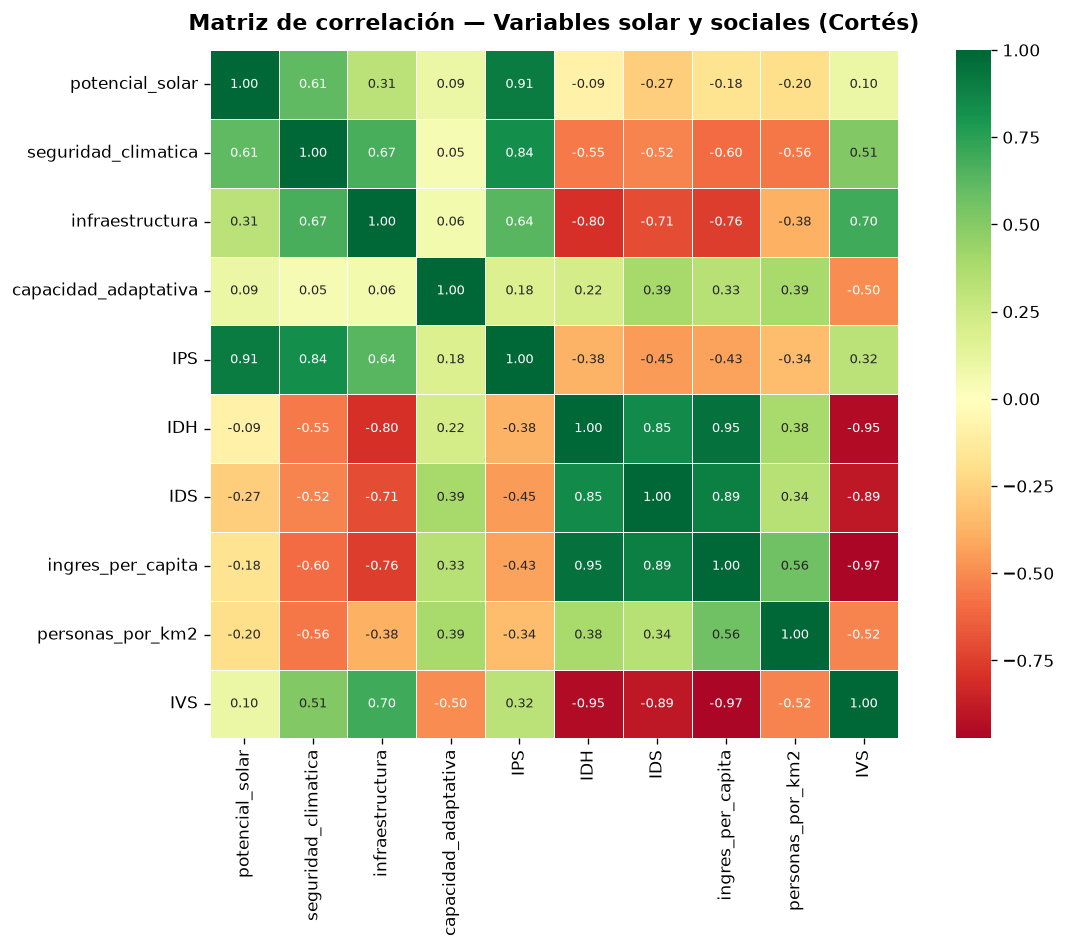

✓ Figura guardada: outputs/heatmap_correlacion_cortes.png


In [10]:
# ── 5.3 Heatmap de correlaciones ─────────────────────────────────────────────
cols_heatmap = [
    'potencial_solar', 'seguridad_climatica', 'infraestructura',
    'capacidad_adaptativa', 'IPS', 'IDH', 'IDS',
    'ingres_per_capita', 'personas_por_km2', 'IVS'
]
corr = df[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriz de correlación — Variables solar y sociales (Cortés)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../outputs/heatmap_correlacion_cortes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: outputs/heatmap_correlacion_cortes.png')

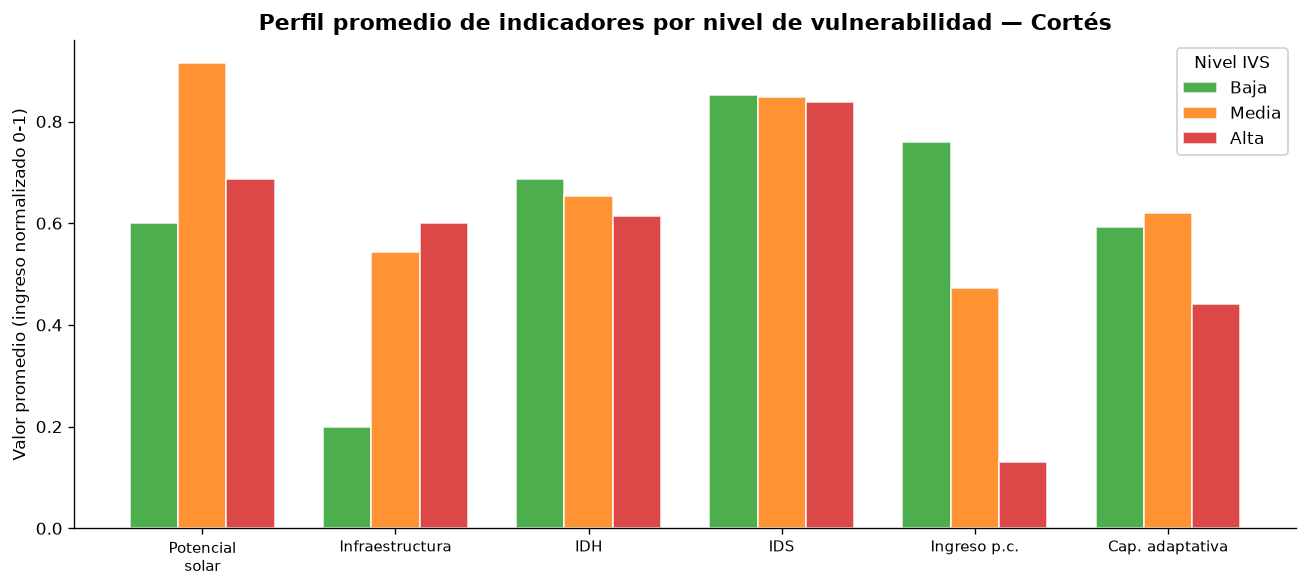

✓ Figura guardada: outputs/perfil_dimensiones_vulnerabilidad.png


In [11]:
# ── 5.4 Perfil por nivel de vulnerabilidad ───────────────────────────────────
dims = ['potencial_solar', 'infraestructura', 'IDH', 'IDS',
        'ingres_per_capita', 'capacidad_adaptativa']
labels = ['Potencial\nsolar', 'Infraestructura', 'IDH', 'IDS',
          'Ingreso p.c.', 'Cap. adaptativa']

df_plot = df.copy()
# Normalizar ingreso para comparación visual
df_plot['ingres_per_capita'] = (df_plot['ingres_per_capita'] -
                                df_plot['ingres_per_capita'].min()) / \
                               (df_plot['ingres_per_capita'].max() -
                                df_plot['ingres_per_capita'].min())

grp_mean = df_plot.groupby('nivel_vulnerabilidad')[dims].mean()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(dims))
width = 0.25
colors_vul = [PALETTE['baja'], PALETTE['media'], PALETTE['alta']]

for i, (nivel, row) in enumerate(grp_mean.iterrows()):
    ax.bar(x + i * width, row.values, width, label=nivel,
           color=colors_vul[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Valor promedio (ingreso normalizado 0-1)', fontsize=10)
ax.set_title('Perfil promedio de indicadores por nivel de vulnerabilidad — Cortés',
             fontsize=13, fontweight='bold')
ax.legend(title='Nivel IVS', framealpha=0.9)
plt.tight_layout()
plt.savefig('../outputs/perfil_dimensiones_vulnerabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: outputs/perfil_dimensiones_vulnerabilidad.png')

## 6. Identificación de municipios prioritarios

Clasificamos los municipios en cuatro cuadrantes estratégicos según su posición relativa en IVS e IPS respecto a la mediana departamental.

In [12]:
# Índice compuesto de prioridad: IVS × IPS (ambos normalizados, peso igual)
ips_norm = (df['IPS'] - df['IPS'].min()) / (df['IPS'].max() - df['IPS'].min())
ivs_norm = (df['IVS'] - df['IVS'].min()) / (df['IVS'].max() - df['IVS'].min())

df['indice_prioridad'] = (0.5 * ivs_norm + 0.5 * ips_norm).round(4)

def cuadrante(row):
    alta_vul = row['IVS'] >= df['IVS'].median()
    alto_sol = row['IPS'] >= df['IPS'].median()
    if alta_vul and alto_sol:
        return 'Q1: Alta vul. + Alto solar'
    elif alta_vul:
        return 'Q2: Alta vul. + Bajo solar'
    elif alto_sol:
        return 'Q3: Baja vul. + Alto solar'
    else:
        return 'Q4: Baja vul. + Bajo solar'

df['cuadrante'] = df.apply(cuadrante, axis=1)

tabla_resumen = df[[
    'municipio', 'IVS', 'IPS', 'IDH', 'ingres_per_capita',
    'capacidad_adaptativa', 'infraestructura',
    'nivel_vulnerabilidad', 'indice_prioridad', 'cuadrante', 'preseleccionado'
]].sort_values('indice_prioridad', ascending=False).reset_index(drop=True)

pd.set_option('display.max_colwidth', 35)
display(tabla_resumen.round(3))

,municipio,IVS,IPS,IDH,ingres_per_capita,capacidad_adaptativa,infraestructura,nivel_vulnerabilidad,indice_prioridad,cuadrante,preseleccionado
0,San Antonio De Cortes,0.894,0.776,0.586,4154,0.495,1.000,Alta,0.979,Q1: Alta vul. + Alto solar,False
1,Santa Cruz De Yojoa,0.824,0.576,0.622,5014,0.262,0.400,Alta,0.793,Q2: Alta vul. + Bajo solar,False
2,San Francisco De Yojoa,0.593,0.720,0.643,5823,0.497,0.375,Alta,0.741,Q1: Alta vul. + Alto solar,False
3,Potrerillos,0.422,0.806,0.639,6442,0.812,0.700,Media,0.686,Q3: Baja vul. + Alto solar,True
4,Pimienta,0.488,0.741,0.650,6316,0.606,0.575,Media,0.685,Q1: Alta vul. + Alto solar,True
5,San Manuel,0.508,0.612,0.656,6189,0.538,0.450,Media,0.608,Q1: Alta vul. + Alto solar,False
6,Omoa,0.817,0.282,0.604,4309,0.513,0.625,Alta,0.585,Q2: Alta vul. + Bajo solar,False
7,Villanueva,0.392,0.590,0.667,7448,0.527,0.450,Media,0.516,Q4: Baja vul. + Bajo solar,False
8,Puerto Cortes,0.375,0.551,0.672,6884,0.612,0.175,Baja,0.478,Q4: Baja vul. + Bajo solar,False
9,La Lima,0.226,0.619,0.703,7997,0.549,0.400,Baja,0.426,Q3: Baja vul. + Alto solar,False


In [13]:
# Municipios en Q1: mayor impacto potencial
q1 = tabla_resumen[tabla_resumen['cuadrante'] == 'Q1: Alta vul. + Alto solar']
print(f'Municipios Q1 (máx. impacto — Alta vulnerabilidad + Alto potencial solar): {len(q1)}')
display(q1[['municipio', 'IVS', 'IPS', 'IDH', 'ingres_per_capita',
            'indice_prioridad', 'preseleccionado']].round(3))

Municipios Q1 (máx. impacto — Alta vulnerabilidad + Alto potencial solar): 4


,municipio,IVS,IPS,IDH,ingres_per_capita,indice_prioridad,preseleccionado
0,San Antonio De Cortes,0.894,0.776,0.586,4154,0.979,False
2,San Francisco De Yojoa,0.593,0.720,0.643,5823,0.741,False
4,Pimienta,0.488,0.741,0.650,6316,0.685,True
5,San Manuel,0.508,0.612,0.656,6189,0.608,False


In [14]:
# Resumen por cuadrante
cuad_summary = df.groupby('cuadrante').agg(
    n_municipios=('municipio', 'count'),
    ivs_medio=('IVS', 'mean'),
    ips_medio=('IPS', 'mean'),
    idh_medio=('IDH', 'mean'),
    ingreso_medio=('ingres_per_capita', 'mean'),
    preseleccionados=('preseleccionado', 'sum'),
).round(3)
display(cuad_summary)

,n_municipios,ivs_medio,ips_medio,idh_medio,ingreso_medio,preseleccionados
cuadrante,,,,,,
Q1: Alta vul. + Alto solar,4,0.621,0.712,0.634,5620.5,1
Q2: Alta vul. + Bajo solar,2,0.820,0.429,0.613,4661.5,0
Q3: Baja vul. + Alto solar,2,0.324,0.713,0.671,7219.5,1
Q4: Baja vul. + Bajo solar,4,0.292,0.408,0.679,7945.0,0


## 7. Exportación de resultados

In [15]:
os.makedirs('../outputs', exist_ok=True)

# Dataset consolidado
df.to_csv('../outputs/vulnerabilidad_social_cortes.csv', index=False)
print('✓ Dataset consolidado → outputs/vulnerabilidad_social_cortes.csv')

# Tabla de prioridad
tabla_resumen.to_csv('../outputs/municipios_prioritarios_cortes.csv', index=False)
print('✓ Tabla de prioridad   → outputs/municipios_prioritarios_cortes.csv')

print()
print('=' * 50)
print('RESUMEN DEL ANÁLISIS DE VULNERABILIDAD — CORTÉS')
print('=' * 50)
print(f'Total municipios analizados    : {len(df)}')
print(f'IVS promedio departamental     : {df["IVS"].mean():.3f}')
print(f'IPS promedio departamental     : {df["IPS"].mean():.3f}')
print(f'Municipios en Q1 (⚡ máx. imp.): {len(q1)}')
print()
print('Top 3 por índice de prioridad:')
for _, row in tabla_resumen.head(3).iterrows():
    flag = '★' if row['preseleccionado'] else ' '
    print(f"  {flag} {row['municipio']:<28}  IVS={row['IVS']:.3f}  "
          f"IPS={row['IPS']:.3f}  Prioridad={row['indice_prioridad']:.3f}")

✓ Dataset consolidado → outputs/vulnerabilidad_social_cortes.csv
✓ Tabla de prioridad   → outputs/municipios_prioritarios_cortes.csv

RESUMEN DEL ANÁLISIS DE VULNERABILIDAD — CORTÉS
Total municipios analizados    : 12
IVS promedio departamental     : 0.495
IPS promedio departamental     : 0.564
Municipios en Q1 (⚡ máx. imp.): 4

Top 3 por índice de prioridad:
    San Antonio De Cortes         IVS=0.894  IPS=0.776  Prioridad=0.979
    Santa Cruz De Yojoa           IVS=0.824  IPS=0.576  Prioridad=0.793
    San Francisco De Yojoa        IVS=0.593  IPS=0.720  Prioridad=0.741
